In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats

Which products are more sale before Christmas?
Hypotheses:
1. Before Christmas, the total_price(Quantity*UnitPrice) increases because pepole buy presents and celebrate

In [3]:
df = pd.read_csv('../data/data.csv', encoding='cp1252')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [11]:
df.shape

(541909, 10)

In [4]:
df['month'] = pd.to_datetime(df['InvoiceDate']).dt.month
df['total_price'] = df['Quantity'] * df['UnitPrice']

<Axes: xlabel='month', ylabel='total_price'>

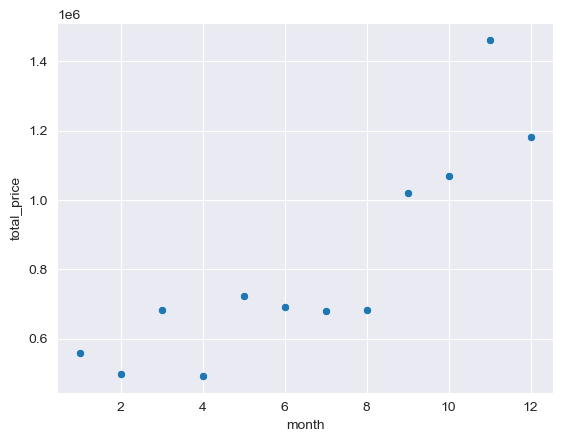

In [5]:
x= df.groupby('month')['total_price'].sum().reset_index()
sns.scatterplot(x='month', y='total_price', data=x)

In [6]:
x_before_christmas = x.loc[x['month'].isin([11,12])]['total_price']
x_christmas_is_far_away = x.loc[~x['month'].isin([11,12])]['total_price']
t_stat, p_value = stats.ttest_ind(x_before_christmas, x_christmas_is_far_away, equal_var=True)   #

print(f"t-statystyka: {t_stat}")
print(f"p-value:      {p_value}")
if p_value < 0.05:
    print("→ Istnieje istotna statystycznie różnica między średnimi")
else:
    print("→ Brak istotnej różnicy między średnimi")

t-statystyka: 4.040393314284726
p-value:      0.0023597305387337056
→ Istnieje istotna statystycznie różnica między średnimi


In [7]:
x2 = df.copy()
x2 = df.groupby(['Description', 'month'])['total_price'].sum().reset_index().sort_values('total_price', ascending=False)
x2['before_christmas'] = x2['month'].isin([11,12])
x2.head(10)

,Description,month,total_price,before_christmas
8695,DOTCOM POSTAGE,12,44543.88,True
20010,PICNIC BASKET WICKER 60 PIECES,6,39619.50,False
8694,DOTCOM POSTAGE,11,36905.40,True
22002,RABBIT NIGHT LIGHT,11,34422.09,True
23095,REGENCY CAKESTAND 3 TIER,12,32800.28,True
19318,PAPER CHAIN KIT 50'S CHRISTMAS,11,28883.04,True
19571,PARTY BUNTING,5,19123.00,False
8693,DOTCOM POSTAGE,10,17955.13,False
23086,REGENCY CAKESTAND 3 TIER,3,16830.60,False
19319,PAPER CHAIN KIT 50'S CHRISTMAS,12,16075.86,True


In [8]:
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

x2 = df.copy()
monthly_sales = x2.groupby(['Description', 'month'])['total_price'].sum().reset_index()
monthly_sales['before_christmas'] = monthly_sales['month'].isin([11, 12])

results = []

for description, data in monthly_sales.groupby('Description'):
    sales_before = data[data['before_christmas'] == True]['total_price']
    sales_after  = data[data['before_christmas'] == False]['total_price']

    if len(sales_before) < 2 or len(sales_after) < 2:
        continue   # too few observations for t-test

    t_stat, p_val = stats.ttest_ind(sales_before, sales_after, equal_var=False)  # Welch

    results.append({
        'Description': description,
        'mean_before': sales_before.mean(),
        'mean_after':  sales_after.mean(),
        'diff': sales_before.mean() - sales_after.mean(),
        'total_before': sales_before.sum(),
        'total_after':  sales_after.sum(),
        'months_before': len(sales_before),
        'months_after':  len(sales_after),
        't_stat': t_stat,
        'p_value': p_val
    })

df_results = pd.DataFrame(results)

# Correction for multiple comparisons
p_values = df_results['p_value'].values
reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

df_results['p_fdr'] = p_corrected
df_results['significant_fdr'] = reject

df_results = df_results.sort_values('p_fdr')

print(f"Number of significantly better products during the holiday season (FDR 5%): {df_results['significant_fdr'].sum()}\n")

print("Top 15 products with the biggest difference (statistically significant):")
print(df_results[df_results['significant_fdr']].head(15)[[
    'Description', 'mean_before', 'mean_after', 'diff', 'p_fdr', 'months_before', 'months_after'
]].round(2))

D:\Ananaconda\envs\data_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Number of significantly better products during the holiday season (FDR 5%): 82

Top 15 products with the biggest difference (statistically significant):
                           Description  mean_before  mean_after     diff  \
10           12 EGG HOUSE PAINTED WOOD       304.05      175.77   128.28   
48            3D SHEET OF DOG STICKERS        71.73       28.05    43.68   
67     5 STRAND GLASS NECKLACE CRYSTAL        37.98        9.49    28.48   
70     6 CHOCOLATE LOVE HEART T-LIGHTS       674.08       83.15   590.92   
84           75 GREEN PETIT FOUR CASES        29.54       12.72    16.83   
98     AIRLINE BAG VINTAGE JET SET RED       331.10      176.11   154.99   
103     ALARM CLOCK BAKELIKE CHOCOLATE      1067.48      584.61   482.87   
141  ANTIQUE SILVER TEA GLASS ENGRAVED      1397.72      746.35   651.37   
157         ASSORTED COLOUR MINI CASES      1979.31      859.20  1120.11   
285             BLUE GLASS GEMS IN BAG         5.78       54.06   -48.28   
302       B

Which products are bought together?
Hypotheses:
1. Buying tea/coffee customer buy something sweet for good combination.


In [12]:
print("How many products are in data in the database?")
len(df['Description'].unique())

How many products are in data in the database?


4224

In [21]:
print("What is the largest amount of products in one order?")
int(df.groupby('InvoiceNo')['Description'].count().max())

What is the largest amount of products in one order?


1114

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,month,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,12,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,12,20.34


In [25]:
df.loc[df.duplicated(keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,month,total_price
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom,12,4.95
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom,12,2.10
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom,12,1.25
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom,12,1.25
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom,12,2.95
...,...,...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,12/9/2011 11:34,0.39,14446.0,United Kingdom,12,0.39
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,12/9/2011 11:34,2.49,14446.0,United Kingdom,12,2.49
541692,581538,22992,REVOLVER WOODEN RULER,1,12/9/2011 11:34,1.95,14446.0,United Kingdom,12,1.95
541699,581538,22694,WICKER STAR,1,12/9/2011 11:34,2.10,14446.0,United Kingdom,12,2.10


This is probably cause of adding the same product one by one without changing quantity so there is no need to drop duplicates.

In [28]:
from itertools import permutations
products_similarity = {product:{'total':0} for product in df['Description'].unique()}

orders = df['InvoiceNo'].unique()
for order in orders:
    products = df['Description'].loc[df['InvoiceNo'] == order].unique()
    permutation_products = permutations(products,2)
    for products in permutation_products:
        if products[1] in products_similarity[products[0]]:
            products_similarity[products[0]][products[1]] += 1
        else:
            products_similarity[products[0]][products[1]] = 1
        products_similarity[products[0]]['total'] += 1


In [35]:
x = pd.DataFrame(products_similarity).T
x.fillna(0, inplace=True)
x.head()

,total,WHITE METAL LANTERN,CREAM CUPID HEARTS COAT HANGER,KNITTED UNION FLAG HOT WATER BOTTLE,RED WOOLLY HOTTIE WHITE HEART.,SET 7 BABUSHKA NESTING BOXES,GLASS STAR FROSTED T-LIGHT HOLDER,EDWARDIAN PARASOL RED,RETRO COFFEE MUGS ASSORTED,SAVE THE PLANET MUG,...,ZINC PLANT POT HOLDER,CAPIZ CHANDELIER,SET 36 COLOUR PENCILS DOILEY,ENAMEL MUG PANTRY,BISCUIT TIN VINTAGE LEAF,CANNISTER VINTAGE LEAF DESIGN,PLAYING CARDS VINTAGE DOILEY,I LOVE LONDON MINI RUCKSACK,SET 36 COLOURING PENCILS DOILEY,SET 12 COLOURING PENCILS DOILEY
WHITE HANGING HEART T-LIGHT HOLDER,137276.0,107.0,113.0,153.0,107.0,98.0,71.0,90.0,52.0,131.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WHITE METAL LANTERN,24377.0,0.0,35.0,42.0,31.0,33.0,26.0,22.0,30.0,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CREAM CUPID HEARTS COAT HANGER,21243.0,35.0,0.0,30.0,22.0,31.0,23.0,17.0,22.0,27.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KNITTED UNION FLAG HOT WATER BOTTLE,43449.0,42.0,30.0,0.0,146.0,44.0,26.0,35.0,38.0,49.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RED WOOLLY HOTTIE WHITE HEART.,33561.0,31.0,22.0,146.0,0.0,42.0,24.0,20.0,33.0,38.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
recommendations = x.drop(['total'], axis=1)
recommendations = recommendations.div(x["total"], axis=0)
recommendations.head()

,WHITE METAL LANTERN,CREAM CUPID HEARTS COAT HANGER,KNITTED UNION FLAG HOT WATER BOTTLE,RED WOOLLY HOTTIE WHITE HEART.,SET 7 BABUSHKA NESTING BOXES,GLASS STAR FROSTED T-LIGHT HOLDER,EDWARDIAN PARASOL RED,RETRO COFFEE MUGS ASSORTED,SAVE THE PLANET MUG,VINTAGE BILLBOARD DRINK ME MUG,...,ZINC PLANT POT HOLDER,CAPIZ CHANDELIER,SET 36 COLOUR PENCILS DOILEY,ENAMEL MUG PANTRY,BISCUIT TIN VINTAGE LEAF,CANNISTER VINTAGE LEAF DESIGN,PLAYING CARDS VINTAGE DOILEY,I LOVE LONDON MINI RUCKSACK,SET 36 COLOURING PENCILS DOILEY,SET 12 COLOURING PENCILS DOILEY
WHITE HANGING HEART T-LIGHT HOLDER,0.000779,0.000823,0.001115,0.000779,0.000714,0.000517,0.000656,0.000379,0.000954,0.000524,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
WHITE METAL LANTERN,0.000000,0.001436,0.001723,0.001272,0.001354,0.001067,0.000902,0.001231,0.001559,0.001190,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CREAM CUPID HEARTS COAT HANGER,0.001648,0.000000,0.001412,0.001036,0.001459,0.001083,0.000800,0.001036,0.001271,0.001036,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KNITTED UNION FLAG HOT WATER BOTTLE,0.000967,0.000690,0.000000,0.003360,0.001013,0.000598,0.000806,0.000875,0.001128,0.000806,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RED WOOLLY HOTTIE WHITE HEART.,0.000924,0.000656,0.004350,0.000000,0.001251,0.000715,0.000596,0.000983,0.001132,0.000745,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
recommendations.to_csv('data/recommendations.csv',)

What product are similar to by name?

In [ ]:
similar_by_name = pd.DataFrame(index=df['Description'].unique(), columns=df['Description'].unique())